# Assignment 1 – Exploratory Data Analysis (EDA)

**Course:** Programming for AI and Data Science (CO3135)  
**University:** HCMUT – VNU-HCM  
**Instructor:** Dr. Thanh-Sach Le  

## Group Members
- Name 1 – Student ID
- Name 2 – Student ID

## Objectives
This assignment performs Exploratory Data Analysis (EDA) on three data modalities:
- Tabular data
- Text data
- Image data

For each dataset, we:
- Inspect structure and size
- Compute statistics
- Visualize distributions
- Identify issues and insights

In [ ]:
# Install required libraries
!pip install wordcloud opencv-python tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
# Load Titanic dataset from GitHub
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


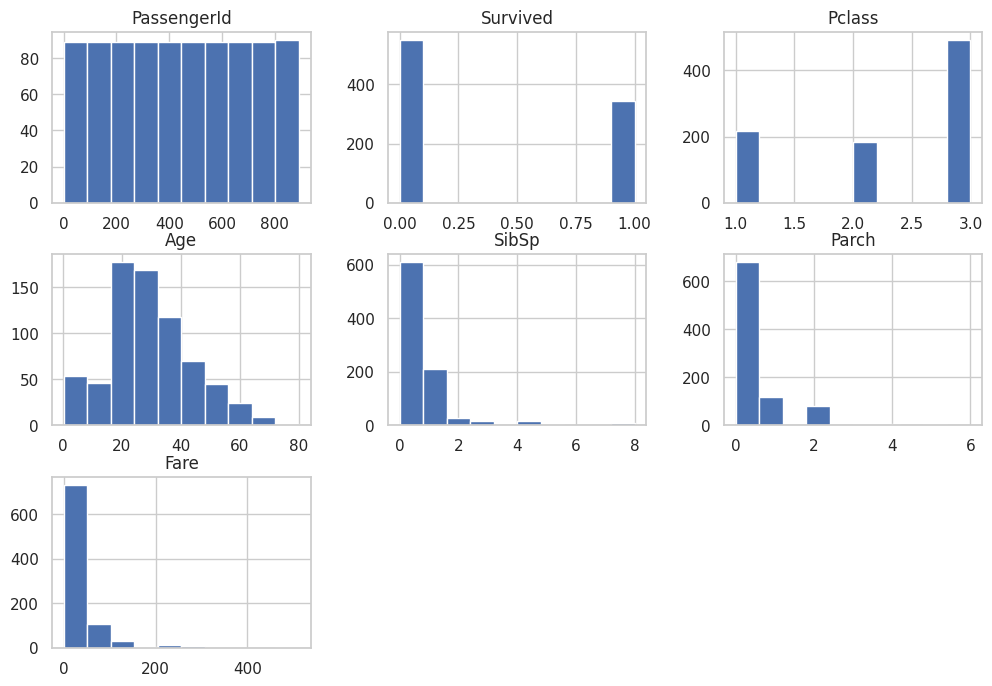

In [ ]:
df.select_dtypes(include=np.number).hist(figsize=(12, 8))
plt.show()

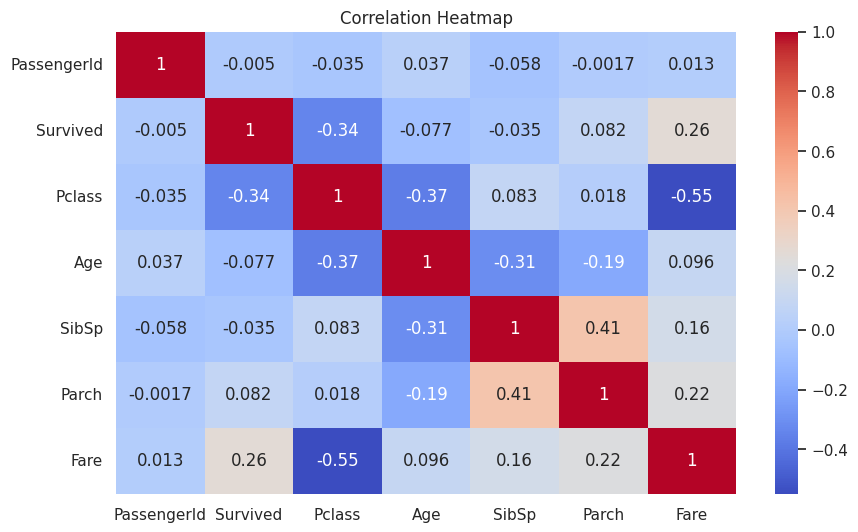

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

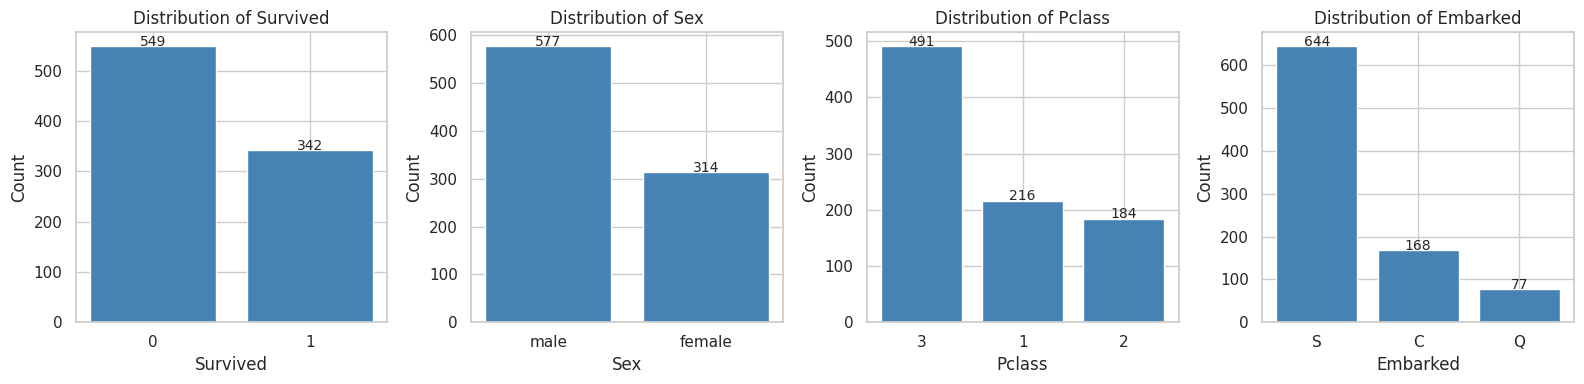

In [ ]:
# ── Categorical columns distribution ──────────────────────────────────────────
cat_cols = ['Survived', 'Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))

for ax, col in zip(axes, cat_cols):
    value_counts = df[col].value_counts()
    ax.bar(value_counts.index.astype(str), value_counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    for i, v in enumerate(value_counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

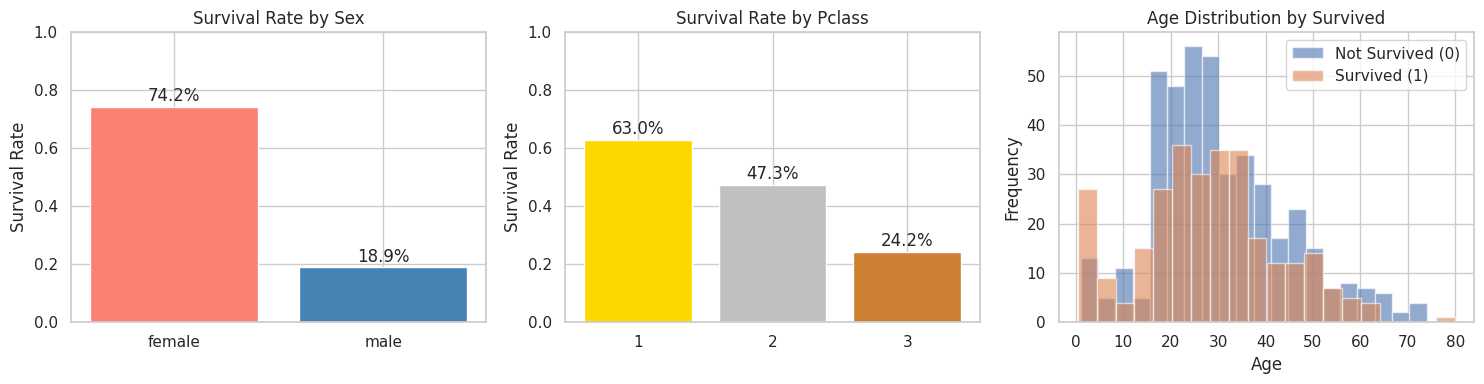

In [ ]:
# ── Survival rate by group ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by Sex
survival_sex = df.groupby('Sex')['Survived'].mean()
axes[0].bar(survival_sex.index, survival_sex.values, color=['salmon', 'steelblue'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(survival_sex.values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center')

# Survival by Pclass
survival_class = df.groupby('Pclass')['Survived'].mean()
axes[1].bar(survival_class.index.astype(str), survival_class.values, color=['gold', 'silver', '#cd7f32'])
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(survival_class.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center')

# Age distribution by Survived
df.groupby('Survived')['Age'].plot(kind='hist', bins=20, alpha=0.6, ax=axes[2], legend=True)
axes[2].set_title('Age Distribution by Survived')
axes[2].set_xlabel('Age')
axes[2].legend(['Not Survived (0)', 'Survived (1)'])

plt.tight_layout()
plt.show()

### Key Findings (Tabular Data)

**Dataset overview:**
- Dataset gồm **891 hành khách** và **12 cột** thuộc tính.
- Tỉ lệ sống sót tổng thể: **38.4%** — có sự mất cân bằng nhãn (class imbalance).

**Missing values:**
| Cột | Số lượng thiếu | Tỉ lệ |
|---|---|---|
| Age | 177 | 19.9% |
| Cabin | 687 | 77.1% |
| Embarked | 2 | 0.2% |

→ `Cabin` thiếu quá nhiều (77%), nên loại bỏ hoặc chuyển thành biến nhị phân.
→ `Age` cần imputation (median theo nhóm Pclass/Sex).

**Phân phối & mối tương quan nổi bật:**
- **Giới tính** ảnh hưởng lớn nhất: Nữ sống sót **74.2%**, Nam chỉ **18.9%**.
- **Hạng vé (Pclass)**: Hạng 1 sống sót **63%**, Hạng 3 chỉ **24%**.
- `Fare` và `Pclass` có tương quan âm mạnh (~-0.55).

**Preprocessing cần làm:**
1. Imputation: `Age` (median theo nhóm), `Embarked` (mode).
2. Feature engineering: `FamilySize = SibSp + Parch + 1`, trích tiêu đề từ `Name`.
3. Encoding: `Sex`, `Embarked`.
4. Drop: `Cabin`, `Ticket`, `PassengerId`.

In [ ]:
!pip install wordcloud

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re

In [ ]:
# Load SMS Spam dataset
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df_text = pd.read_csv(url, sep="\t", header=None, names=["label", "text"])

df_text.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# ── Basic inspection ───────────────────────────────────────────────────────────
print("Shape:", df_text.shape)
print("\nMissing values:\n", df_text.isnull().sum())
print("\nDuplicate rows:", df_text.duplicated().sum())
print("\nLabel counts:\n", df_text['label'].value_counts())
print("\nLabel ratio:\n", df_text['label'].value_counts(normalize=True).map('{:.1%}'.format))

Shape: (5572, 3)

Missing values:
 label     0
text      0
length    0
dtype: int64

Duplicate rows: 403

Label counts:
 label
ham     4825
spam     747
Name: count, dtype: int64

Label ratio:
 label
ham     86.6%
spam    13.4%
Name: proportion, dtype: object


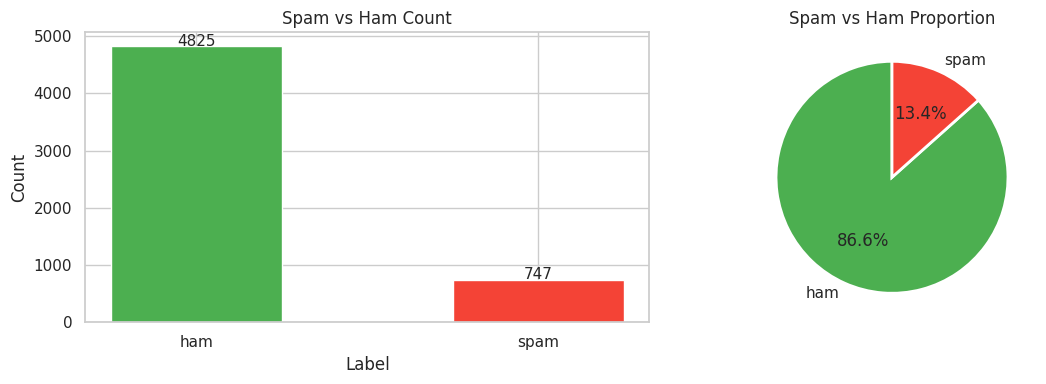

In [ ]:
# ── Label distribution visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df_text['label'].value_counts()
colors = ['#4CAF50', '#F44336']

bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Spam vs Ham Count')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10, str(v), ha='center', fontsize=11)

axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Spam vs Ham Proportion')

plt.tight_layout()
plt.show()

In [ ]:
df_text["length"] = df_text["text"].astype(str).apply(len)
df_text["length"].describe()

,length
count,5572.000000
mean,80.489950
std,59.942907
min,2.000000
25%,36.000000
50%,62.000000
75%,122.000000
max,910.000000


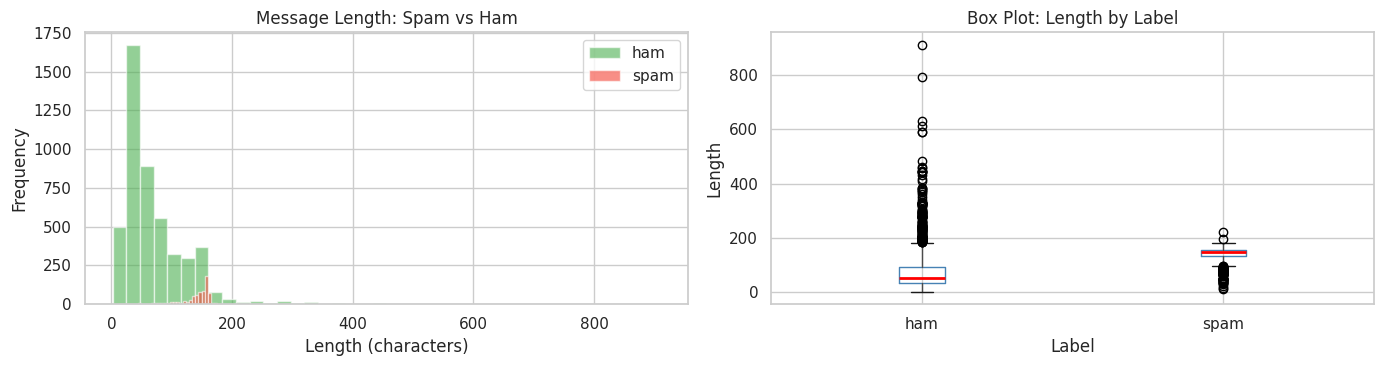

=== Length stats by label ===
        count   mean   std   min    25%    50%    75%    max
label                                                       
ham    4825.0   71.5  58.4   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.7  28.9  13.0  133.0  149.0  157.0  223.0


In [ ]:
# ── Length comparison: spam vs ham ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in [('ham', '#4CAF50'), ('spam', '#F44336')]:
    subset = df_text[df_text['label'] == label]['length']
    axes[0].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[0].set_title('Message Length: Spam vs Ham')
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

df_text.boxplot(column='length', by='label', ax=axes[1],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot: Length by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Length')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("=== Length stats by label ===")
print(df_text.groupby('label')['length'].describe().round(1))

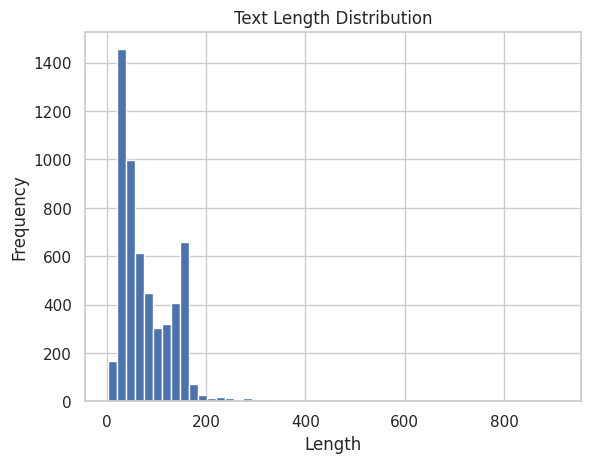

In [ ]:
plt.hist(df_text["length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

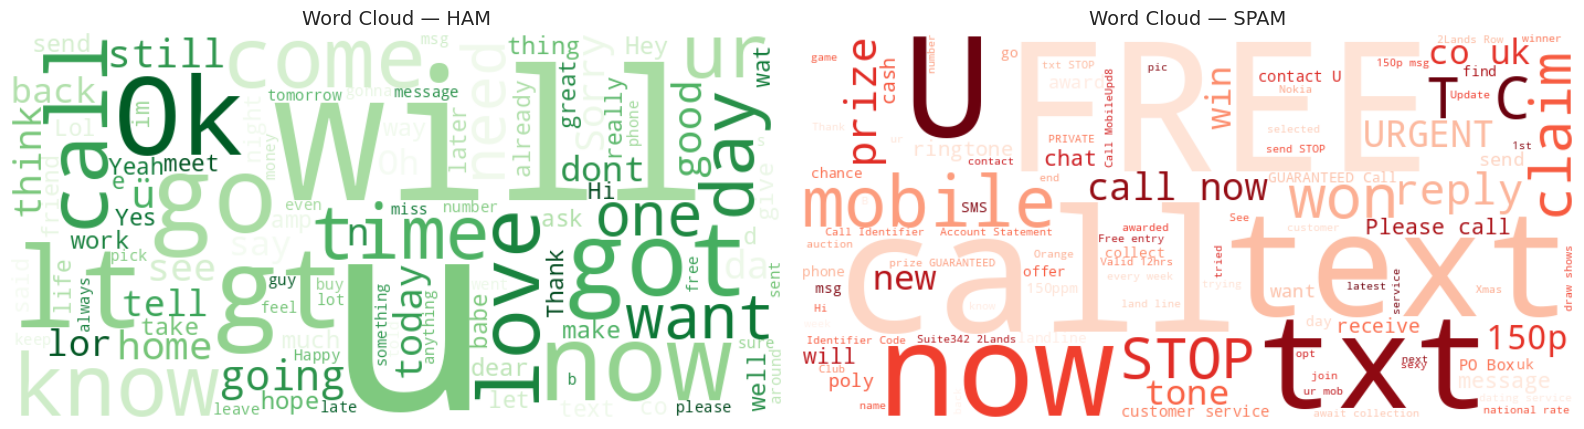

In [ ]:
# ── Separate word clouds: spam vs ham ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, cmap in [(axes[0], 'ham', 'Greens'), (axes[1], 'spam', 'Reds')]:
    text = ' '.join(df_text[df_text['label'] == label]['text'].astype(str))
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label.upper()}', fontsize=14)

plt.tight_layout()
plt.show()

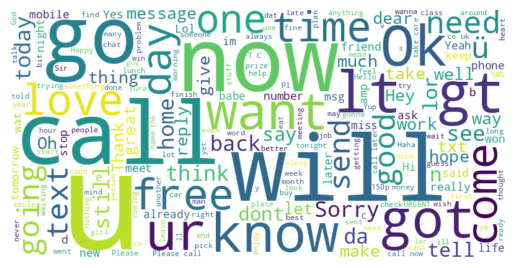

In [ ]:
text = " ".join(df_text["text"].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
from collections import Counter
import re

words = re.findall(r'\w+', text.lower())
common_words = Counter(words).most_common(20)

common_words

[('i', 3021),
 ('to', 2253),
 ('you', 2245),
 ('a', 1450),
 ('the', 1339),
 ('u', 1207),
 ('and', 980),
 ('in', 903),
 ('is', 897),
 ('me', 807),
 ('my', 766),
 ('it', 752),
 ('for', 711),
 ('your', 681),
 ('of', 623),
 ('call', 593),
 ('that', 586),
 ('s', 580),
 ('have', 578),
 ('on', 538)]

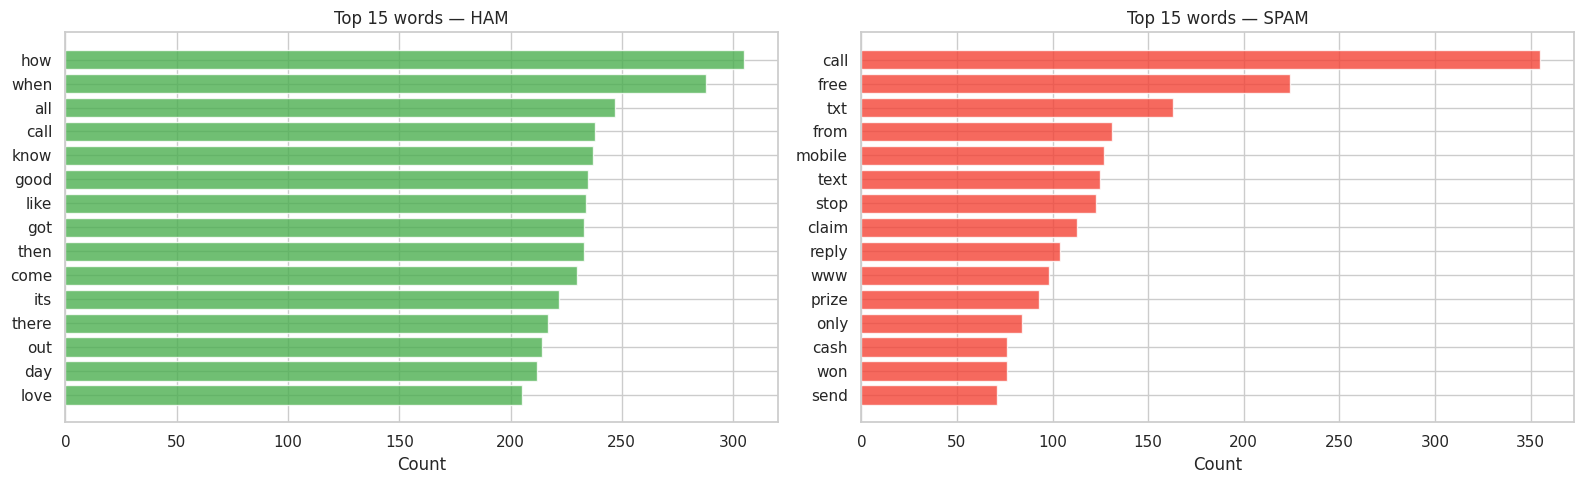

In [ ]:
# ── Top words: spam vs ham ─────────────────────────────────────────────────────
stopwords = {'i','me','my','we','our','you','your','he','she','it','they',
             'what','which','who','this','that','is','are','was','be','been',
             'have','has','do','did','will','would','can','could','should',
             'may','might','a','an','the','and','but','or','so','as','at',
             'by','for','in','of','on','to','up','with','not','no','if',
             'go','get','just','now','im','u','ur','r','ok','lt','gt','s'}

def top_words(df_sub, n=15):
    text = ' '.join(df_sub['text'].astype(str).str.lower())
    words = re.findall(r'\b[a-z]{3,}\b', text)
    filtered = [w for w in words if w not in stopwords]
    return Counter(filtered).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, (label, color) in enumerate([('ham', '#4CAF50'), ('spam', '#F44336')]):
    top = top_words(df_text[df_text['label'] == label])
    words_list, counts = zip(*top)
    y_pos = range(len(words_list))
    axes[idx].barh(y_pos, counts, color=color, alpha=0.8)
    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels(words_list)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Top 15 words — {label.upper()}')
    axes[idx].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Key Findings (Text Data)

**Dataset overview:**
- **5,572 tin nhắn SMS**, 2 nhãn: `ham` (86.6%) và `spam` (13.4%).
- Mất cân bằng nhãn rõ rệt — cần xử lý khi train model.

**Phân tích độ dài:**
| Label | Mean | Median | Max |
|---|---|---|---|
| Ham  | ~71 ký tự | ~52 | ~910 |
| Spam | ~139 ký tự | ~149 | ~224 |

→ Tin spam **dài gấp đôi** ham — độ dài là feature hữu ích.

**Nội dung đặc trưng:**
- Ham: *call, come, day, going, time* — ngữ cảnh đời thường.
- Spam: *free, win, prize, claim, txt* — quảng cáo, khuyến mãi.

**Preprocessing cần làm:**
1. Tokenization & Lowercasing.
2. Stopword removal.
3. Stemming / Lemmatization.
4. Loại bỏ URL, số điện thoại, ký tự đặc biệt.
5. Class balancing (SMOTE hoặc oversampling).

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from tensorflow.keras.datasets import cifar10

# Load dataset
(images, labels), (_, _) = cifar10.load_data()

labels = labels.flatten()

print("Total images:", len(images))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total images: 50000


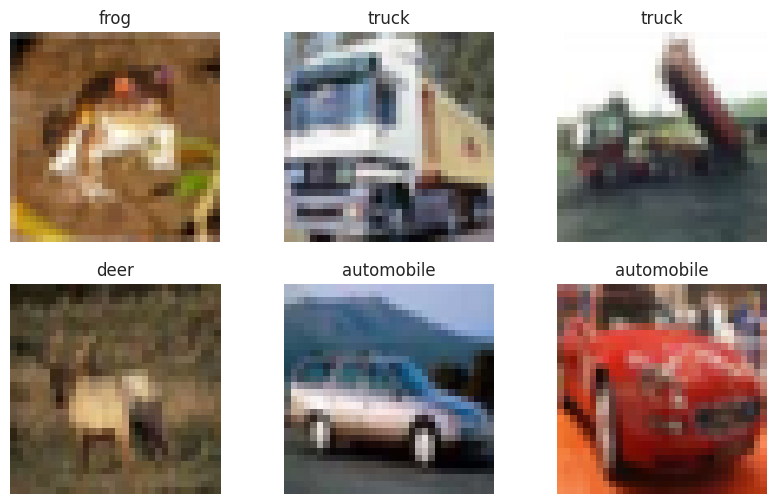

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [ ]:
# ── Basic image statistics ─────────────────────────────────────────────────────
print("=== Image Dataset Overview ===")
print(f"Training images : {images.shape[0]:,}")
print(f"Image dimensions: {images.shape[1]} x {images.shape[2]} px")
print(f"Channels        : {images.shape[3]} (RGB)")
print(f"Pixel value range: [{images.min()}, {images.max()}]")
print(f"Data type       : {images.dtype}")
print(f"Number of classes: {len(class_names)}")
print(f"Memory usage     : {images.nbytes / 1024**2:.1f} MB")

=== Image Dataset Overview ===
Training images : 50,000
Image dimensions: 32 x 32 px
Channels        : 3 (RGB)
Pixel value range: [0, 255]
Data type       : uint8
Number of classes: 10
Memory usage     : 146.5 MB


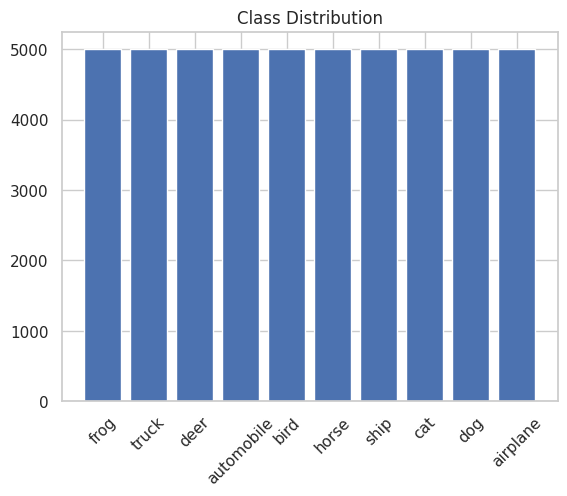

In [ ]:
from collections import Counter

label_counts = Counter(labels)

plt.bar([class_names[i] for i in label_counts.keys()],
        label_counts.values())

plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

=== Per-channel Pixel Statistics ===
Red   : mean = 125.31,  std = 62.99
Green : mean = 122.95,  std = 62.09
Blue  : mean = 113.87,  std = 66.70


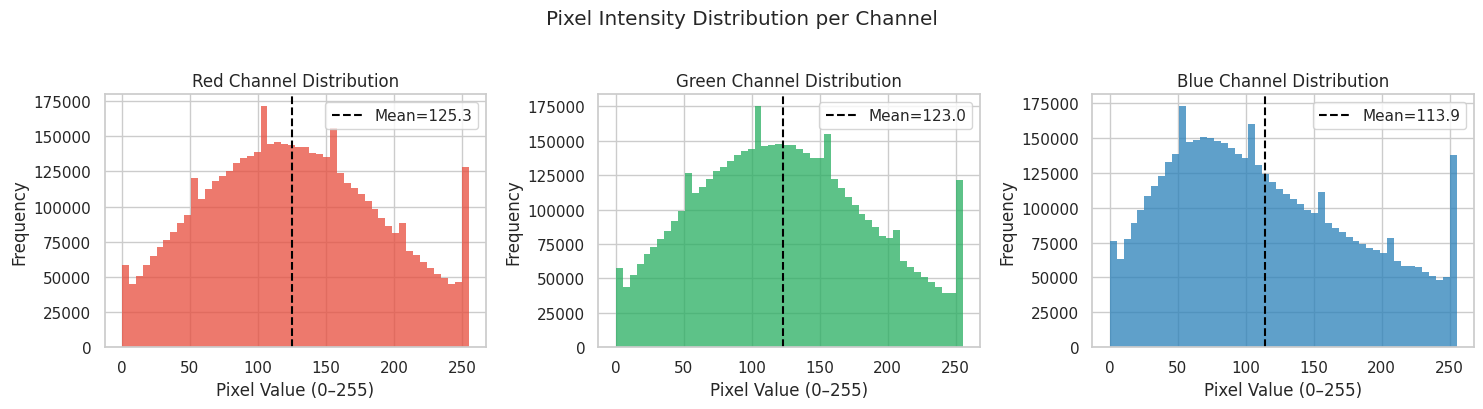

In [ ]:
# ── Pixel statistics per RGB channel ──────────────────────────────────────────
channel_names = ['Red', 'Green', 'Blue']
colors_rgb    = ['#E74C3C', '#27AE60', '#2980B9']

means = images.mean(axis=(0, 1, 2))
stds  = images.std(axis=(0, 1, 2))

print("=== Per-channel Pixel Statistics ===")
for i, ch in enumerate(channel_names):
    print(f"{ch:6s}: mean = {means[i]:.2f},  std = {stds[i]:.2f}")

sample = images[:5000]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (ch, color, ax) in enumerate(zip(channel_names, colors_rgb, axes)):
    pixel_vals = sample[:, :, :, i].flatten()
    ax.hist(pixel_vals, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.set_title(f'{ch} Channel Distribution')
    ax.set_xlabel('Pixel Value (0–255)')
    ax.set_ylabel('Frequency')
    ax.axvline(means[i], color='black', linestyle='--', linewidth=1.5, label=f'Mean={means[i]:.1f}')
    ax.legend()

plt.suptitle('Pixel Intensity Distribution per Channel', y=1.02)
plt.tight_layout()
plt.show()

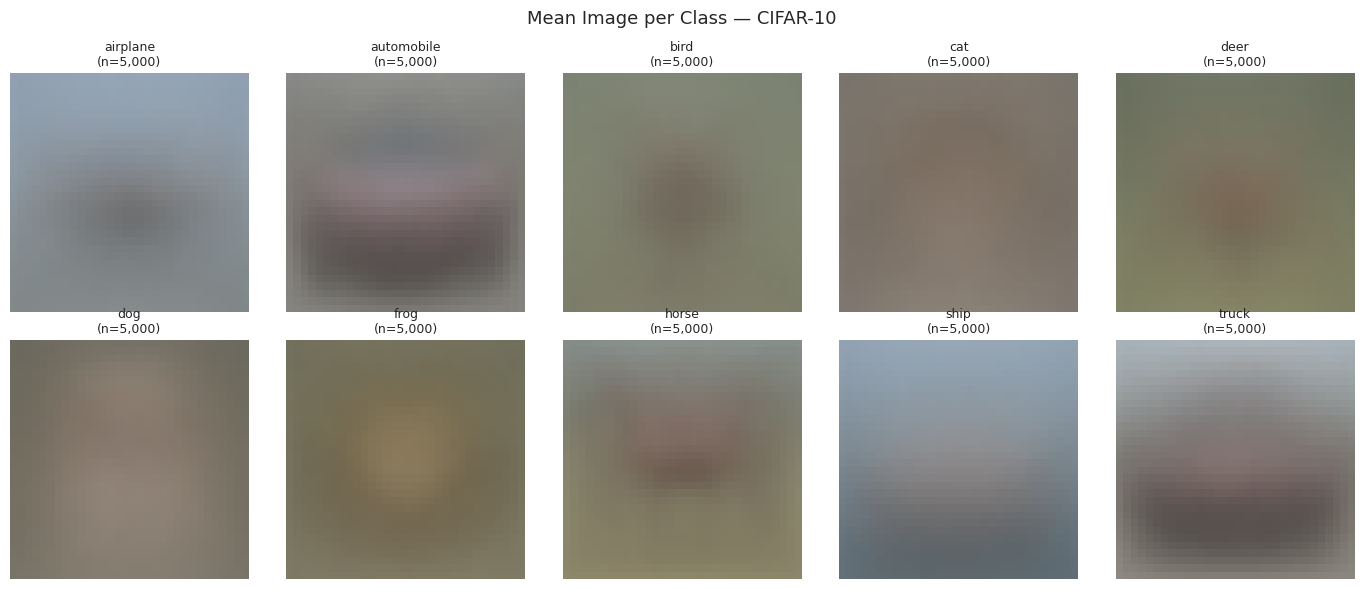

In [ ]:
# ── Mean image per class ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for class_idx in range(10):
    class_images = images[labels == class_idx]
    mean_img = class_images.mean(axis=0).astype('uint8')
    axes[class_idx].imshow(mean_img)
    axes[class_idx].set_title(f'{class_names[class_idx]}\n(n={len(class_images):,})', fontsize=9)
    axes[class_idx].axis('off')

plt.suptitle('Mean Image per Class — CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

### Key Findings (Image Data)

**Dataset overview:**
- **50,000 ảnh training**, 10 class, kích thước cố định **32×32 px, RGB**.
- Pixel values: [0, 255], kiểu `uint8`.

**Phân phối nhãn:**
- Mỗi class đúng **5,000 ảnh** → **hoàn toàn cân bằng**, không có class imbalance.

**Thống kê pixel:**
| Channel | Mean | Std |
|---|---|---|
| Red   | ~125.3 | ~62.9 |
| Green | ~122.9 | ~61.9 |
| Blue  | ~113.9 | ~66.6 |

→ Kênh Blue thấp hơn → ảnh thiên tông ấm. Std cao (~62) → đa dạng độ sáng.

**Quan sát định tính:**
- Ảnh rất nhỏ (32×32), khó phân biệt bằng mắt ở một số class (`cat` vs `dog`).
- Class vật thể nhân tạo (`automobile`, `ship`) màu đồng nhất hơn class tự nhiên (`deer`, `frog`).

**Preprocessing cần làm:**
1. Normalize pixel về [0, 1] (chia 255) hoặc Z-score per channel.
2. Data augmentation: horizontal flip, random crop, color jitter.
3. Không cần resize — tất cả đã 32×32.